<a href="https://colab.research.google.com/github/zFonta/CEIA-TF-Chess-DL/blob/main/notebooks/04_train_campaign.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 - Primera campaña de entrenamiento de la ResNet

Tareas **4.3** (función de pérdida) y **4.4** (primera campaña y diagnóstico)
del WBS. La notebook `03` dejó el entorno listo y midió los pisos; esta
entrena de verdad.

**Los números contra los que se lee todo**, medidos en la notebook 03 sobre
el split de validación:

| Referencia | RMSE | R² |
|---|---|---|
| Media constante | 0,4886 | 0,000 |
| Material lineal | **0,3973** | 0,339 |

La red tiene que quedar por debajo de 0,3973 o no se justifica.

> **Reanudable.** Después de cada época el estado completo —pesos, optimizador,
> scheduler, generadores aleatorios e historial— se sube a Hugging Face. Si
> Colab corta la sesión, se vuelve a correr la misma celda y sigue donde
> estaba: una desconexión cuesta como mucho una época.


## 1. Entorno


In [1]:
# Clonar el repositorio e instalar el paquete.
# Idempotente: se puede volver a correr tal cual despues de una desconexion.
import os, sys, subprocess, importlib
from pathlib import Path

REPO_DIR = Path("/content/CEIA-TF-Chess-DL")
if not REPO_DIR.exists():
    subprocess.run(["git", "clone", "https://github.com/zFonta/CEIA-TF-Chess-DL.git", str(REPO_DIR)], check=True)
else:
    subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only"], check=True)

os.chdir(REPO_DIR)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", ".[dev]"], check=True)

# pip registra el paquete editable con un .pth, y los .pth solo se procesan al
# arrancar el interprete: un kernel que ya esta corriendo no lo ve. Agregar src/
# a sys.path lo hace visible sin tener que reiniciar el runtime.
src = str(REPO_DIR / "src")
if src not in sys.path:
    sys.path.insert(0, src)
importlib.invalidate_caches()

# Stockfish con version fija. Entrenar no lo usa, pero sin el se saltean los 17
# tests de integracion del pipeline, que son la evidencia del requerimiento 3.2.
subprocess.run(["bash", "scripts/setup_stockfish.sh"], check=True)
os.environ["PATH"] = f"{REPO_DIR}/bin:" + os.environ["PATH"]

print("Listo. Directorio de trabajo:", os.getcwd())

Listo. Directorio de trabajo: /content/CEIA-TF-Chess-DL


In [2]:
import numpy as np
import torch
from chessdl.colab import TRAINING, describe_runtime

runtime = describe_runtime(phase=TRAINING)
print("GPU disponible :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Modelo de GPU  :", torch.cuda.get_device_name(0))
print("CPU workers    :", runtime.cpu_count)
print("torch          :", torch.__version__)
for aviso in runtime.warnings():
    print("AVISO:", aviso)

GPU disponible : True
Modelo de GPU  : Tesla T4
CPU workers    : 2
torch          : 2.11.0+cu128


## 2. Tests


In [3]:
!{sys.executable} -m pytest -q

........................................................................ [ 22%]
........................................................................ [ 44%]
........................................................................ [ 66%]
........................................................................ [ 88%]
....................................                                     [100%]
324 passed in 53.38s


## 3. Dataset, partición y caché

Lo mismo que hizo la notebook 03. Si el caché ya está en disco no se
reconstruye; si el runtime es nuevo, se vuelve a armar (unos minutos).


In [4]:
from chessdl.config import load_config
from chessdl import hf
from chessdl.data import schema
from chessdl.training.split import describe_split, leaked_games, split_masks
from chessdl.training.cache import build_cache, cache_path_for, load_cache

cfg = load_config()
token = hf.get_token()

directorio = hf.download_dataset(cfg.output.hf_repo_id, "/content/ceia-chess/hub")
tabla = schema.read_dataset(schema.shard_paths(directorio))

fens     = tabla["fen"].to_pylist()
game_ids = tabla["game_id"].to_pylist()
targets  = np.asarray(tabla["value_stm"], dtype=np.float32)

split_cfg = cfg.training.split_config()
masks = split_masks(game_ids, split_cfg)
assert not leaked_games(masks, game_ids)
print(describe_split(masks, game_ids))

ruta_cache = cache_path_for(cfg.training.cache_dir)
if not ruta_cache.exists():
    build_cache(fens, ruta_cache, progress=True)
cache = load_cache(ruta_cache, expected_rows=len(fens))

idx_train = np.flatnonzero(masks['train'])
idx_val   = np.flatnonzero(masks['val'])
idx_test  = np.flatnonzero(masks['test'])
print(f"\nCache {cache.shape} -- train {len(idx_train):,} / val {len(idx_val):,} / test {len(idx_test):,}")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 158 files:   0%|          | 0/158 [00:00<?, ?it/s]

split       posiciones       %    partidas
------------------------------------------
train        2,297,785  90.01%     695,480
val            127,520   5.00%      38,654
test           127,499   4.99%      38,663


encoding:   0%|          | 0/2552804 [00:00<?, ?pos/s]


Cache (2552804, 18, 8, 8) -- train 2,297,785 / val 127,520 / test 127,499


## 4. Los pisos de referencia

Se recalculan acá para que la campaña sea autocontenida: el `TrainingRun`
guarda estos números junto al historial, así el checkpoint sabe contra qué
se lo estaba comparando.


In [5]:
from chessdl.training.baselines import material_baseline, mean_baseline

rng = np.random.default_rng(0)
sub = np.sort(rng.choice(idx_train, size=min(200_000, len(idx_train)), replace=False))

media = mean_baseline(targets[idx_train], targets[idx_val])
material, _ = material_baseline(np.asarray(cache[sub]), targets[sub],
                                np.asarray(cache[idx_val]), targets[idx_val])
print(media)
print(material)

pisos = {'media': media.rmse, 'material': material.rmse}

media constante             RMSE 0.4886   MAE 0.3778
material (lineal)           RMSE 0.3973   MAE 0.3052


## 5. La pérdida (tarea 4.3)

Se arranca con **MSE**: la tarea es regresión sobre un escalar acotado y la
métrica que decide la comparación es RMSE, así que entrenar sobre el error
cuadrático optimiza exactamente lo que se reporta.

**Huber** queda instrumentado como alternativa para la tarea 4.5, y el motivo
es propio de este dataset: las etiquetas no están repartidas suavemente sobre
[-1, 1]. Un 1,43 % son mates clavados en ±0,9999 y el recorte a ±2000
centipeones apila más masa en los extremos. MSE pondera por el cuadrado del
error, así que esas posiciones saturadas dominan el gradiente — y son
justamente donde el valor exacto importa menos, porque "gana" y "gana más"
son lo mismo a la hora de elegir una jugada.


In [6]:
from chessdl.training.loss import describe_loss, saturated_share

saturadas = saturated_share(torch.from_numpy(targets[idx_train]))
print(f"Perdida configurada : {describe_loss(cfg.training.loss)}")
print(f"Etiquetas saturadas : {saturadas:.2%} del split de entrenamiento")
print("  (es el numero que motiva probar Huber en 4.5)")

Perdida configurada : MSE
Etiquetas saturadas : 1.53% del split de entrenamiento
  (es el numero que motiva probar Huber en 4.5)


## 6. El modelo y el destino de los checkpoints


In [7]:
from chessdl.models.resnet import ChessResNet, ResNetConfig
from chessdl.training.loop import seed_everything
from chessdl.training.checkpoint import HubCheckpoints

arquitectura = ResNetConfig(channels=128, blocks=8)

# La siembra va ANTES de construir el modelo. train() tambien siembra, pero
# para entonces los pesos iniciales ya salieron del estado en que estuviera
# el interprete, y no serian reproducibles entre sesiones.
#
# OJO: los resultados guardados mas abajo son de la campana que se corrio
# ANTES de agregar esta linea, asi que volver a correr la notebook da
# numeros parecidos pero no identicos. De aca en adelante si lo son.
seed_everything(cfg.training.split_seed)

modelo = ChessResNet(arquitectura)
print(modelo.describe())

# Cada corrida tiene su propio prefijo en el repo, asi el transformer de la
# tarea 4.8 no pisa los pesos de la ResNet.
RUN = 'resnet-128x8-mse'
repo_modelos = f'{cfg.output.hf_namespace}/{cfg.training.hf_models_repo}'

checkpoints = HubCheckpoints(
    repo_id=repo_modelos,
    run_name=RUN,
    local_dir='/content/ceia-chess/checkpoints',
    token=token,
    enabled=cfg.training.push_to_hub and token is not None,
)
print('Checkpoints ->', repo_modelos, '/', RUN)
print('Subida al Hub:', checkpoints.enabled)

ResNet 128 canales x 8 bloques (cabeza 32/256) -- 2,913,345 parametros
Checkpoints -> zFonta/ceia-chess-models / resnet-128x8-mse
Subida al Hub: True


## 7. La campaña

**Esta es la celda larga.** Si Colab corta, se la vuelve a correr tal cual:
detecta el checkpoint en el Hub y sigue desde la época siguiente. No hay que
cambiar ningún parámetro al reanudar — de hecho **no hay que cambiarlos**,
porque `epochs` define el schedule del learning rate y bajarlo a mitad de
camino configuraría una corrida distinta, no una continuación.


In [8]:
from chessdl.training.loop import train

resultado = train(
    modelo, cache, targets, idx_train, idx_val,
    epochs=cfg.training.epochs,
    batch_size=cfg.training.batch_size,
    learning_rate=cfg.training.learning_rate,
    weight_decay=cfg.training.weight_decay,
    loss_name=cfg.training.loss,
    seed=cfg.training.split_seed,
    checkpoints=checkpoints,
    model_config={'channels': arquitectura.channels, 'blocks': arquitectura.blocks},
    baselines=pisos,
)

resnet-128x8-mse/checkpoint_last.pt: reconstructing file:   0%|          |  0.00B / 35.1MB            

resnet-128x8-mse/checkpoint_last.pt: downloading bytes:           |  0.00B            

Reanudando desde la epoca 30.


## 8. Diagnóstico de la campaña


In [9]:
print(resultado.summary())

 epoca     train   val RMSE   val MAE   MAE cp    signo     rho     seg
-----------------------------------------------------------------------
     1   0.12655     0.3218    0.2360    145.1   77.9%  0.7134     219
     2   0.09996     0.4499    0.3523    203.9   69.3%  0.6262     227
     3   0.09173     0.3442    0.2555    153.5   77.6%  0.7169     227
     4   0.08553     0.3655    0.2752    163.8   74.9%  0.7010     226
     5   0.08032     0.3509    0.2538    150.5   75.2%  0.7337     226
     6   0.07603     0.2878    0.2064    128.3   82.6%  0.7914     226
     7   0.07239     0.2859    0.2049    126.9   81.1%  0.7773     226
     8   0.06899     0.2699    0.1875    118.9   84.2%  0.8011     226
     9   0.06597     0.2712    0.1870    118.5   84.7%  0.8015     226
    10   0.06334     0.3109    0.2272    135.7   78.5%  0.7860     227
    11   0.06076     0.2754    0.1899    119.7   83.8%  0.8053     226
    12   0.05847     0.2766    0.1952    122.6   83.7%  0.8093     226
    

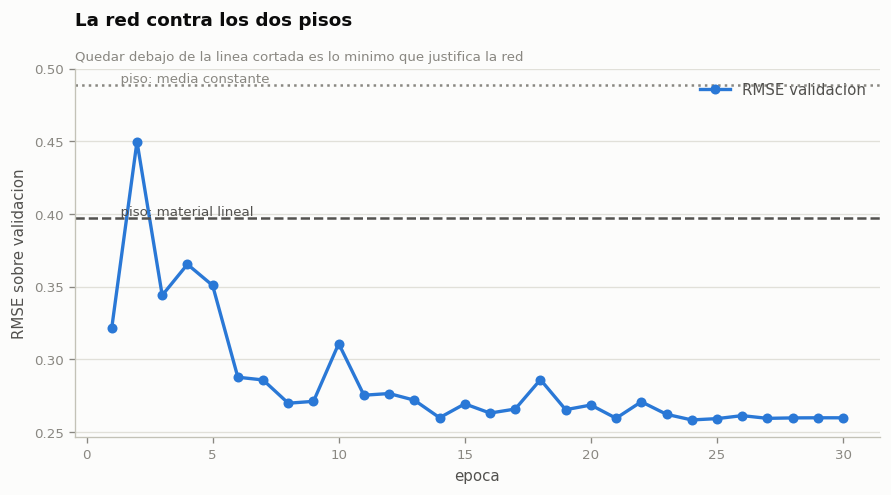

In [10]:
import matplotlib.pyplot as plt
from chessdl import viz

viz.apply_style()
epocas = [e.epoch for e in resultado.history.epochs]

fig, ax = plt.subplots()
ax.plot(epocas, [e.val_rmse for e in resultado.history.epochs],
        marker='o', color=viz.SERIES[0], label='RMSE validacion')
ax.axhline(pisos['material'], color=viz.INK_SECONDARY, linestyle='--', linewidth=1.5)
ax.text(epocas[0], pisos['material'], '  piso: material lineal',
        color=viz.INK_SECONDARY, fontsize=8, va='bottom')
ax.axhline(pisos['media'], color=viz.INK_MUTED, linestyle=':', linewidth=1.5)
ax.text(epocas[0], pisos['media'], '  piso: media constante',
        color=viz.INK_MUTED, fontsize=8, va='bottom')
ax.legend(loc='upper right')
viz.label_axes(ax, 'La red contra los dos pisos', 'epoca', 'RMSE sobre validacion',
               note='Quedar debajo de la linea cortada es lo minimo que justifica la red')
fig.tight_layout()

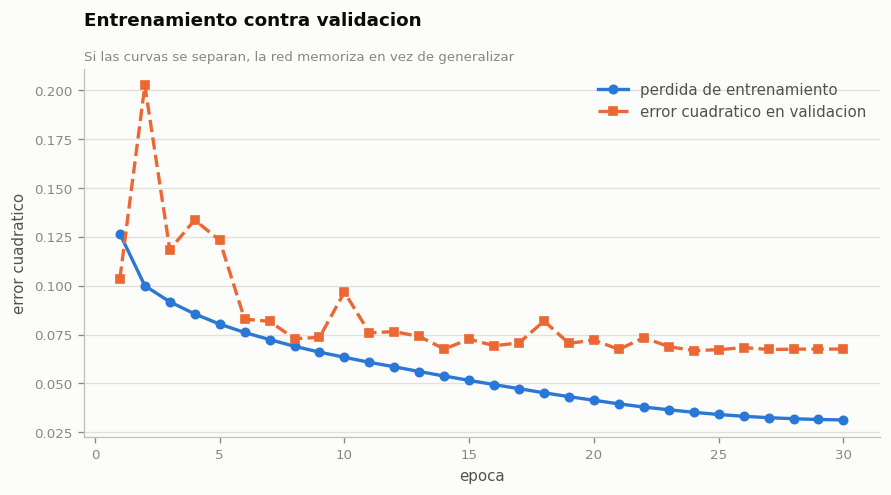

In [11]:
# Sobreajuste: la perdida de entrenamiento contra el error de validacion.
fig, ax = plt.subplots()
ax.plot(epocas, [e.train_loss for e in resultado.history.epochs],
        marker='o', color=viz.SERIES[0], label='perdida de entrenamiento')
ax.plot(epocas, [e.val_rmse ** 2 for e in resultado.history.epochs],
        marker='s', linestyle='--', color=viz.SERIES[1], label='error cuadratico en validacion')
ax.legend(loc='upper right')
viz.label_axes(ax, 'Entrenamiento contra validacion', 'epoca', 'error cuadratico',
               note='Si las curvas se separan, la red memoriza en vez de generalizar')
fig.tight_layout()

## 9. Evaluación final sobre test (tarea 4.7)

El split de test se toca **una sola vez**, con el mejor checkpoint por
validación. Usarlo para elegir entre configuraciones lo convertiría en un
segundo conjunto de validación y dejaría de medir generalización.


In [12]:
from chessdl.training.checkpoint import BEST_NAME, load_checkpoint
from chessdl.training.loop import evaluate_split

dispositivo = 'cuda' if torch.cuda.is_available() else 'cpu'

mejor = checkpoints.fetch(BEST_NAME)
if mejor is not None:
    load_checkpoint(mejor, modelo, map_location=dispositivo)
    print('Cargado el mejor checkpoint por validacion.')

# El modelo puede estar en CPU si esta celda se corre sin haber corrido la
# campana en este kernel (por ejemplo tras perder el runtime). load_state_dict
# copia valores y no mueve el modulo, asi que moverlo aca hace la celda
# autosuficiente en vez de depender de que la celda 8 lo haya hecho.
modelo = modelo.to(dispositivo)

metricas_test = evaluate_split(modelo, cache, targets, idx_test, dispositivo)
print()
print('TEST')
print(metricas_test.summary())

resnet-128x8-mse/checkpoint_best.pt: reconstructing file:   0%|          |  0.00B / 35.1MB            

resnet-128x8-mse/checkpoint_best.pt: downloading bytes:           |  0.00B            

Cargado el mejor checkpoint por validacion.

TEST
posiciones                     127,499
RMSE (value)                    0.2609
MAE (value)                     0.1698
MAE (centipeones)                110.5
acuerdo de signo               86.74%
Spearman                        0.8240


In [13]:
# Tiempo de inferencia por lote, como dato para el bloque 5.
# No es la verificacion del requerimiento 1.7: eso depende de donde corra el
# motor, y el motor todavia no existe.
import time
from chessdl.training.cache import cached_to_tensor

modelo.eval()
lote = torch.from_numpy(cached_to_tensor(np.asarray(cache[idx_test[:40]]))).to(dispositivo)
with torch.no_grad():
    for _ in range(5): modelo(lote)          # calentar
    if dispositivo == 'cuda': torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(50): modelo(lote)
    if dispositivo == 'cuda': torch.cuda.synchronize()
    dt = (time.perf_counter() - t0) / 50

print(f'40 posiciones (una busqueda de un nivel) en {dispositivo}: {dt*1000:.2f} ms')
print(f'  -> {40/dt:,.0f} posiciones/segundo')

40 posiciones (una busqueda de un nivel) en cuda: 3.45 ms
  -> 11,596 posiciones/segundo


## 10. Resumen de la campaña


In [14]:
mejor_epoca = resultado.best
print(f"{'Arquitectura':<32}{modelo.describe()}")
print(f"{'Epocas corridas':<32}{resultado.final_epoch}")
print(f"{'Mejor epoca (validacion)':<32}{mejor_epoca.epoch}")
print()
print(f"{'':<32}{'RMSE':>10}{'R2':>10}")
print('-' * 62)
for nombre, valor in [('media constante', pisos['media']),
                      ('material lineal', pisos['material']),
                      ('ResNet (validacion)', mejor_epoca.val_rmse),
                      ('ResNet (test)', metricas_test.rmse)]:
    r2 = 1 - (valor / pisos['media']) ** 2
    print(f"{nombre:<32}{valor:>10.4f}{r2:>10.3f}")
print()
mejora = (pisos['material'] - metricas_test.rmse) / pisos['material']
print(f"Sobre el piso de material: {'mejora' if mejora > 0 else 'EMPEORA'} {abs(mejora):.1%}")
print(f"Pesos y metricas en: https://huggingface.co/{repo_modelos}")

Arquitectura                    ResNet 128 canales x 8 bloques (cabeza 32/256) -- 2,913,345 parametros
Epocas corridas                 30
Mejor epoca (validacion)        24

                                      RMSE        R2
--------------------------------------------------------------
media constante                     0.4886     0.000
material lineal                     0.3973     0.339
ResNet (validacion)                 0.2584     0.720
ResNet (test)                       0.2609     0.715

Sobre el piso de material: mejora 34.3%
Pesos y metricas en: https://huggingface.co/zFonta/ceia-chess-models
